# 01 — Data Ingestion

Pulls historical **prices**, **volumes**, and **fundamentals** from Yahoo Finance for all candidates.

**Run this notebook first.** Outputs saved to `data/` for downstream notebooks.

| Output file | Contents |
|---|---|
| `data/prices.parquet` | OHLCV close prices |
| `data/returns.parquet` | Daily simple returns |
| `data/log_returns.parquet` | Daily log returns |
| `data/volumes.parquet` | Volume |
| `data/fundamentals.parquet` | Valuation + profitability metrics |

In [1]:
# Install dependencies (run once)
import subprocess, sys
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt', '-q'],
    capture_output=True, text=True
)
print(result.stdout[-500:] if result.stdout else 'Done')
print(result.stderr[-300:] if result.returncode != 0 else '')

Done



In [2]:
import os, sys, warnings
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded.')

Libraries loaded.


In [3]:
sys.path.insert(0, '.')
from config import *

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Long candidate : {LONG_CANDIDATE}')
print(f'Short basket   : {SHORT_CANDIDATES}')
print(f'Sector ETF     : {SECTOR_ETF}')
print(f'Market index   : {MARKET_INDEX}')
print(f'Lookback       : {LOOKBACK_YEARS} years')

Long candidate : GEVO
Short basket   : ['CHPT', 'BE', 'RUN', 'ARRY', 'HYLN', 'RIVN', 'LCID', 'GOEV', 'ALTO', 'REI', 'PARR', 'AFRM', 'GPRE', 'PLUG', 'AMTX']
Sector ETF     : XLK
Market index   : SPY
Lookback       : 5 years


In [4]:
ALL_STOCKS  = [LONG_CANDIDATE] + SHORT_CANDIDATES
ALL_TICKERS = ALL_STOCKS + [SECTOR_ETF, MARKET_INDEX]

end_dt   = pd.Timestamp.today().normalize()
start_dt = end_dt - pd.DateOffset(years=LOOKBACK_YEARS)

print(f'Total tickers : {ALL_TICKERS}')
print(f'Period        : {start_dt.date()} to {end_dt.date()}')

Total tickers : ['GEVO', 'CHPT', 'BE', 'RUN', 'ARRY', 'HYLN', 'RIVN', 'LCID', 'GOEV', 'ALTO', 'REI', 'PARR', 'AFRM', 'GPRE', 'PLUG', 'AMTX', 'XLK', 'SPY']
Period        : 2021-04-02 to 2026-04-02


In [5]:
print('Downloading price data from Yahoo Finance...')
raw = yf.download(ALL_TICKERS, start=start_dt, end=end_dt,
                  auto_adjust=True, progress=True)

if isinstance(raw.columns, pd.MultiIndex):
    prices  = raw['Close'].dropna(how='all')
    volumes = raw['Volume'].dropna(how='all')
else:
    prices  = raw[['Close']].rename(columns={'Close': ALL_TICKERS[0]})
    volumes = raw[['Volume']].rename(columns={'Volume': ALL_TICKERS[0]})

print(f'\nShape         : {prices.shape}')
print(f'Date range    : {prices.index[0].date()} -> {prices.index[-1].date()}')
print(f'\nMissing values:')
print(prices.isnull().sum())
prices.tail(3)

[*********************100%***********************]  18 of 18 completed


Shape         : (1255, 18)
Date range    : 2021-04-05 -> 2026-04-01

Missing values:
Ticker
AFRM      0
ALTO      0
AMTX      0
ARRY      0
BE        0
CHPT      0
GEVO      0
GOEV      0
GPRE      0
HYLN      0
LCID      0
PARR      0
PLUG      0
REI       0
RIVN    154
RUN       0
SPY       0
XLK       0
dtype: int64


Ticker,AFRM,ALTO,AMTX,ARRY,BE,CHPT,GEVO,GOEV,GPRE,HYLN,LCID,PARR,PLUG,REI,RIVN,RUN,SPY,XLK
Date,,,,,,,,,,,,,,,,,,
2026-03-30,43.0300,4.5900,3.2500,6.8800,119.5100,4.5100,2.7800,0.3700,16.5300,1.6600,9.1500,63.9000,2.1400,1.6100,14.4900,12.1400,631.9700,127.5000
2026-03-31,45.8200,4.8400,3.1900,7.2300,135.4900,4.8600,2.7300,0.3700,16.4500,1.7600,9.5300,62.6400,2.2600,1.5300,15.0500,13.5600,650.3400,132.9000
2026-04-01,45.5400,4.7900,2.9800,7.5500,132.4500,4.7800,2.4000,0.3700,16.2300,1.7500,9.5600,61.6700,2.2500,1.4000,14.9400,14.1500,655.2400,134.9100


In [6]:
# Forward-fill then drop any remaining NaNs
# ffill is used to handle non-trading days (weekends, holidays) by carrying forward the last available price/volume
prices  = prices.ffill().dropna()
volumes = volumes.ffill().dropna()

# Compute returns
returns_all  = prices.pct_change().dropna()
log_returns  = np.log(prices / prices.shift(1)).dropna()

# Save
prices.to_parquet(DATA_DIR + 'prices.parquet')
volumes.to_parquet(DATA_DIR + 'volumes.parquet')
returns_all.to_parquet(DATA_DIR + 'returns.parquet')
log_returns.to_parquet(DATA_DIR + 'log_returns.parquet')

print(f'Saved prices ({prices.shape}), returns ({returns_all.shape}), log_returns, volumes.')

Saved prices ((1101, 18)), returns ((1100, 18)), log_returns, volumes.


In [7]:
# Summary statistics
sr = returns_all[ALL_STOCKS]
ann_ret = (1 + sr).prod() ** (252 / len(sr)) - 1
ann_vol = sr.std() * np.sqrt(252)
sharpe  = (ann_ret - RISK_FREE_RATE) / ann_vol
max_dd  = (sr + 1).cumprod().div((sr + 1).cumprod().cummax()).sub(1).min()

stats = pd.DataFrame({
    'Ann Return': ann_ret.map('{:.1%}'.format),
    'Ann Vol':    ann_vol.map('{:.1%}'.format),
    'Sharpe':     sharpe.map('{:.2f}'.format),
    'Max DD':     max_dd.map('{:.1%}'.format),
    'Role': ['LONG'] + ['SHORT'] * len(SHORT_CANDIDATES)
})
stats.index.name = 'Ticker'
print('Return Statistics (full history):')
display(stats)

Return Statistics (full history):


,Ann Return,Ann Vol,Sharpe,Max DD,Role
Ticker,,,,,
GEVO,-22.1%,93.6%,-0.29,-93.4%,LONG
CHPT,-65.4%,81.1%,-0.87,-99.2%,SHORT
BE,37.5%,85.0%,0.38,-74.9%,SHORT
RUN,-26.4%,94.0%,-0.33,-90.3%,SHORT
ARRY,-20.5%,83.7%,-0.30,-85.3%,SHORT
HYLN,-28.5%,86.4%,-0.39,-93.2%,SHORT
RIVN,-35.4%,78.2%,-0.52,-95.1%,SHORT
LCID,-57.7%,81.1%,-0.77,-98.4%,SHORT
GOEV,-87.9%,114.5%,-0.81,-100.0%,SHORT


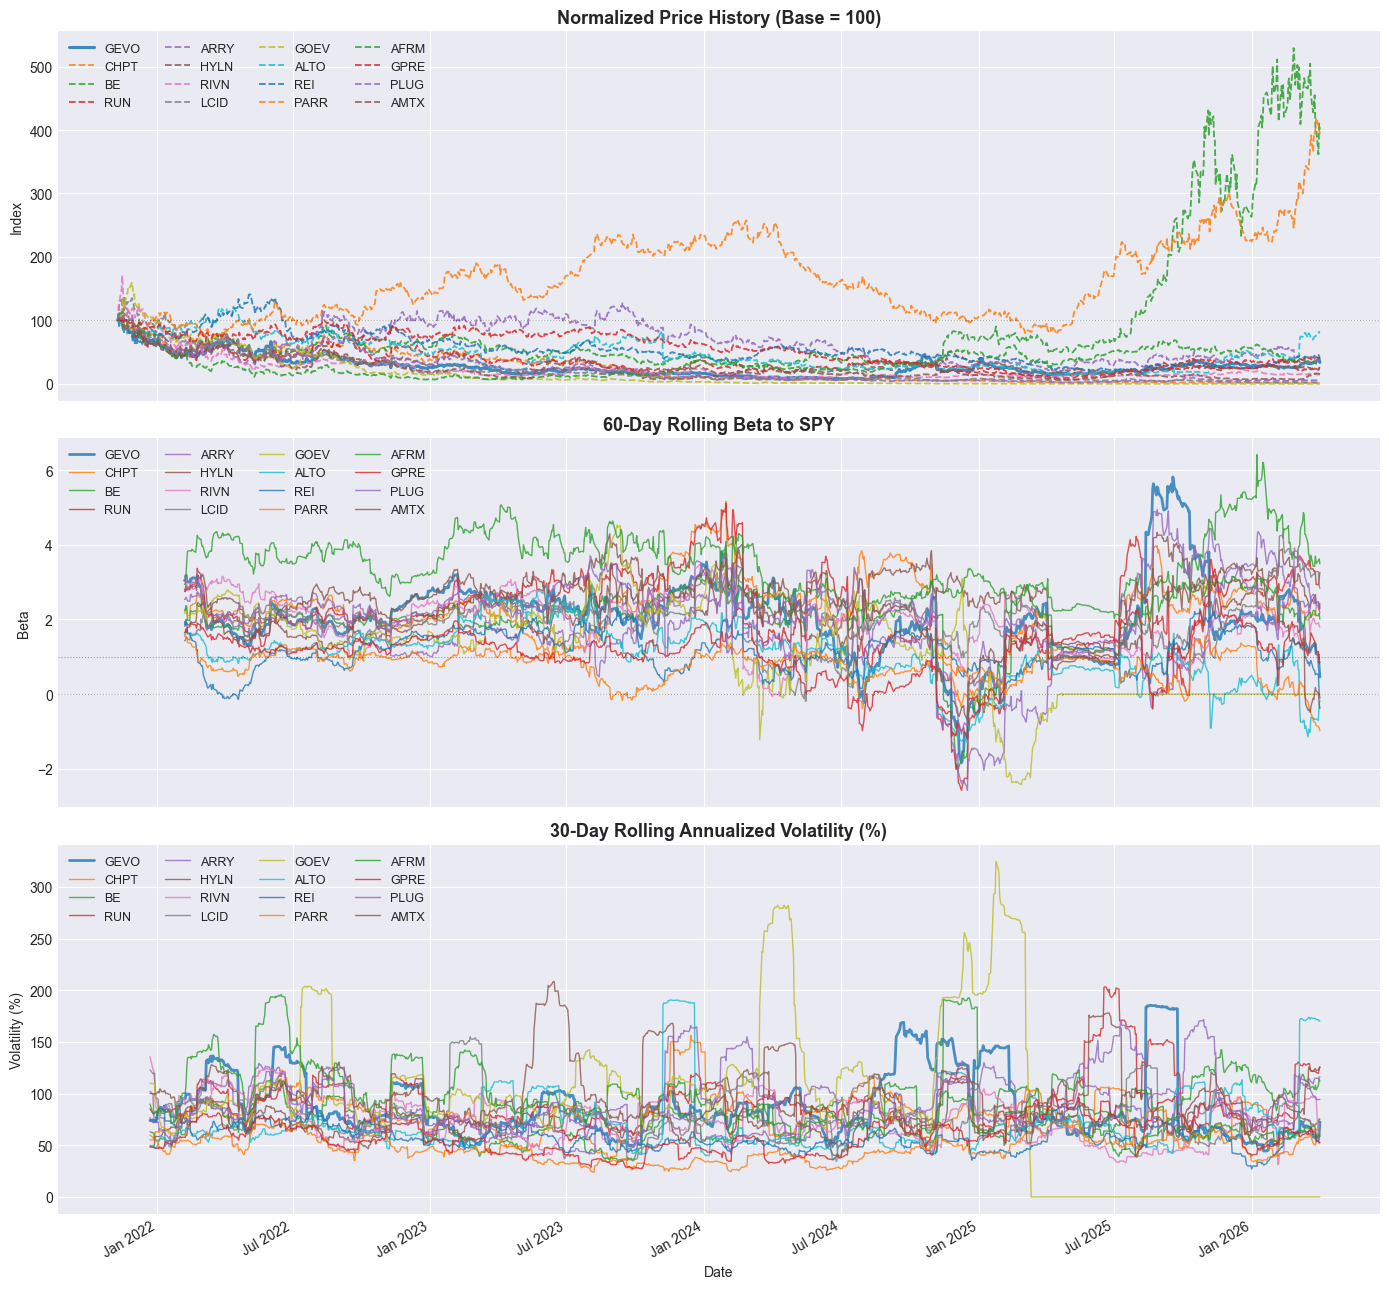

Chart saved to outputs/


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

# Panel 1: Normalized prices
norm = prices[ALL_STOCKS] / prices[ALL_STOCKS].iloc[0] * 100
for col in norm.columns:
    lw = 2.2 if col == LONG_CANDIDATE else 1.3
    ls = '-'  if col == LONG_CANDIDATE else '--'
    norm[col].plot(ax=axes[0], linewidth=lw, linestyle=ls, label=col, alpha=0.85)
axes[0].axhline(100, color='black', lw=0.8, alpha=0.35, linestyle=':')
axes[0].set_title('Normalized Price History (Base = 100)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Index')
axes[0].legend(ncol=4, fontsize=9)

# Panel 2: 60-day rolling beta to SPY
mkt_r = returns_all[MARKET_INDEX]
for col in ALL_STOCKS:
    cov = returns_all[col].rolling(60).cov(mkt_r)
    var = mkt_r.rolling(60).var()
    beta = cov / var
    lw = 2.0 if col == LONG_CANDIDATE else 1.0
    beta.plot(ax=axes[1], linewidth=lw, label=col, alpha=0.8)
axes[1].axhline(1, color='black', lw=0.8, alpha=0.35, linestyle=':')
axes[1].axhline(0, color='black', lw=0.8, alpha=0.35, linestyle=':')
axes[1].set_title('60-Day Rolling Beta to SPY', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Beta')
axes[1].legend(ncol=4, fontsize=9)

# Panel 3: Rolling volatility
for col in ALL_STOCKS:
    lw = 2.0 if col == LONG_CANDIDATE else 1.0
    (returns_all[col].rolling(30).std() * np.sqrt(252) * 100).plot(
        ax=axes[2], linewidth=lw, label=col, alpha=0.8)
axes[2].set_title('30-Day Rolling Annualized Volatility (%)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Volatility (%)')
axes[2].legend(ncol=4, fontsize=9)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig(OUTPUT_DIR + '01_price_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to outputs/')

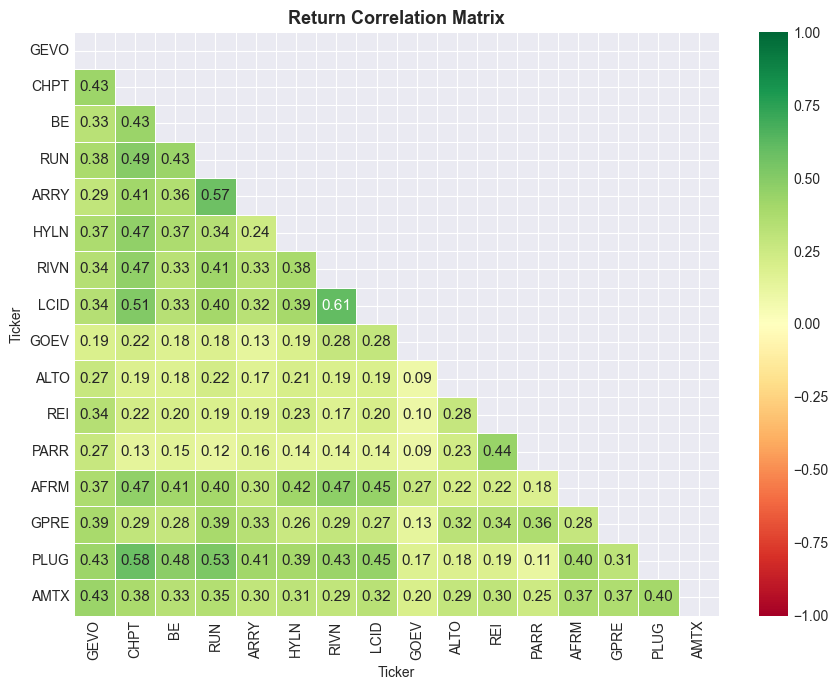

In [9]:
# Correlation matrix heatmap
fig, ax = plt.subplots(figsize=(9, 7))
corr = returns_all[ALL_STOCKS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 11}, linewidths=0.5)
ax.set_title('Return Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '01_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print('Pulling fundamental data from Yahoo Finance...')
fundamentals = {}
for ticker in ALL_STOCKS:
    try:
        info = yf.Ticker(ticker).info
        fundamentals[ticker] = {
            'short_name':      info.get('shortName', ticker),
            'sector':          info.get('sector', 'N/A'),
            'industry':        info.get('industry', 'N/A'),
            'market_cap_bn':   round((info.get('marketCap') or 0) / 1e9, 2),
            'beta':            info.get('beta'),
            'pe_trailing':     info.get('trailingPE'),
            'pe_forward':      info.get('forwardPE'),
            'pb_ratio':        info.get('priceToBook'),
            'ev_ebitda':       info.get('enterpriseToEbitda'),
            'ev_revenue':      info.get('enterpriseToRevenue'),
            'roe':             info.get('returnOnEquity'),
            'roa':             info.get('returnOnAssets'),
            'gross_margin':    info.get('grossMargins'),
            'op_margin':       info.get('operatingMargins'),
            'net_margin':      info.get('profitMargins'),
            'debt_equity':     info.get('debtToEquity'),
            'revenue_growth':  info.get('revenueGrowth'),
            'earnings_growth': info.get('earningsGrowth'),
            'dividend_yield':  info.get('dividendYield'),
            'peg_ratio':       info.get('pegRatio'),
        }
        print(f'  {ticker}: OK')
    except Exception as e:
        print(f'  {ticker}: Error - {e}')
        fundamentals[ticker] = {}

fund_df = pd.DataFrame(fundamentals).T
fund_df.index.name = 'Ticker'
fund_df.to_parquet(DATA_DIR + 'fundamentals.parquet')
print(f'\nFundamentals saved. Shape: {fund_df.shape}')
display(fund_df)

Pulling fundamental data from Yahoo Finance...
  GEVO: OK
  CHPT: OK
  BE: OK
  RUN: OK
  ARRY: OK
  HYLN: OK
  RIVN: OK
  LCID: OK
  GOEV: OK
  ALTO: OK
  REI: OK
  PARR: OK
  AFRM: OK
  GPRE: OK
  PLUG: OK
  AMTX: OK

Fundamentals saved. Shape: (16, 20)


,short_name,sector,industry,market_cap_bn,beta,pe_trailing,pe_forward,pb_ratio,ev_ebitda,ev_revenue,roe,roa,gross_margin,op_margin,net_margin,debt_equity,revenue_growth,earnings_growth,dividend_yield,peg_ratio
Ticker,,,,,,,,,,,,,,,,,,,,
GEVO,"Gevo, Inc.",Basic Materials,Specialty Chemicals,0.5800,1.5180,None,-118.9900,1.2056,101.8500,4.0960,-0.0679,-0.0181,0.3874,-0.1182,-0.2107,35.5550,6.9560,None,None,None
CHPT,"ChargePoint Holdings, Inc.",Consumer Cyclical,Specialty Retail,0.1100,1.4380,None,-1.9954,5.3833,-1.3360,0.5950,-2.7738,-0.1554,0.3054,-0.4847,-0.5355,1274.8390,0.0730,None,None,None
BE,Bloom Energy Corporation,Industrials,Electrical Equipment & Parts,37.7200,3.1830,None,45.7199,48.9836,271.3280,18.6390,-0.1265,0.0157,0.2965,0.1327,-0.0437,377.7980,0.3590,-0.9880,None,None
RUN,Sunrun Inc.,Technology,Solar,3.1700,2.4610,7.9012,30.0967,1.0076,32.0010,6.4870,-0.2206,-0.0037,0.3034,0.0840,0.1522,297.8810,1.2350,None,None,None
ARRY,"Array Technologies, Inc.",Technology,Solar,1.1200,1.7870,None,8.3529,-5.4219,14.9180,1.6680,-0.1902,0.0495,0.2555,-0.0790,-0.0407,294.2510,-0.1790,None,None,None
HYLN,Hyliion Holdings Corp.,Consumer Cyclical,Auto Parts,0.3000,2.6910,None,-6.3333,1.5789,-3.7760,64.2240,-0.2621,-0.1743,0.0489,-21.6559,0.0000,2.2770,-0.5280,None,None,None
RIVN,"Rivian Automotive, Inc.",Consumer Cyclical,Auto Manufacturers,18.9700,1.7490,None,-7.9351,4.1526,-6.3130,3.2820,-0.6501,-0.1480,0.0267,-0.6477,-0.6768,113.0820,-0.2580,None,None,None
LCID,"Lucid Group, Inc.",Consumer Cyclical,Auto Manufacturers,3.2500,1.1940,None,-2.2461,4.5230,-2.2890,5.1590,-0.6602,-0.2427,-0.9281,-2.0369,-1.9930,106.5290,1.2290,None,None,None
GOEV,Canoo Inc.,Consumer Cyclical,Auto Manufacturers,0.0100,None,None,-0.1630,0.1513,-0.6490,69.3290,-0.7267,-0.2517,-0.8702,-48.4141,0.0000,48.6680,0.7170,None,None,None


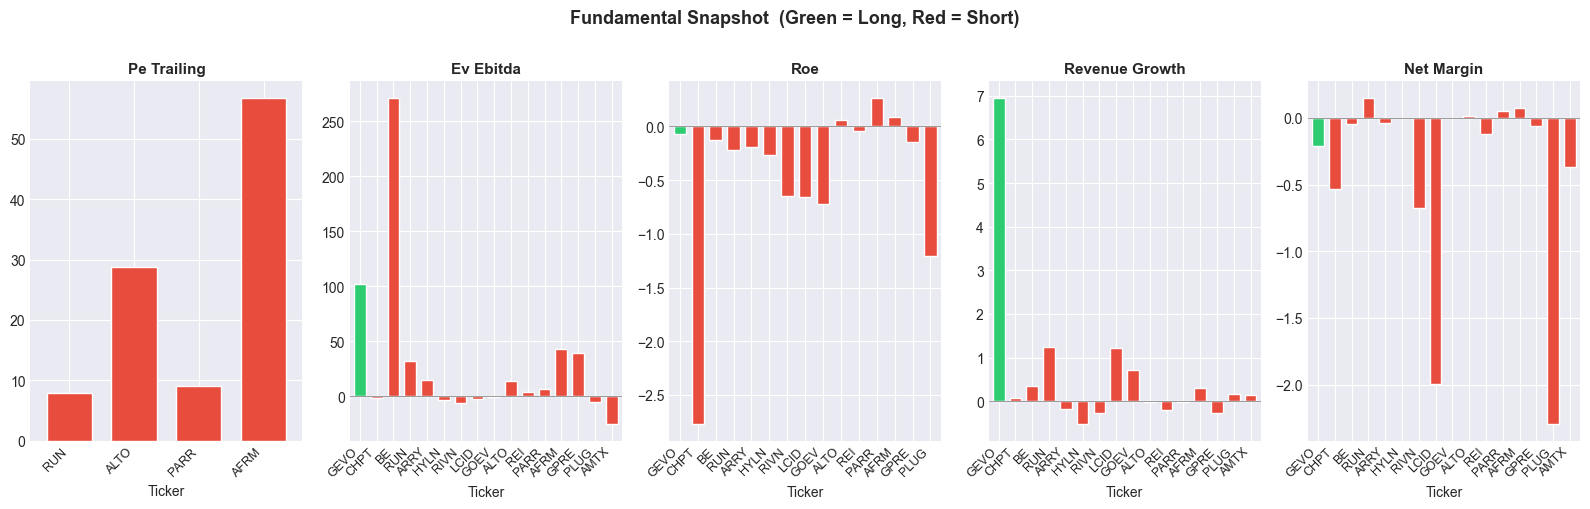


Notebook 01 complete. Run 02_factor_analysis.ipynb next.


In [11]:
# Quick fundamental bar comparison for numeric columns
numeric_cols = ['pe_trailing', 'ev_ebitda', 'roe', 'revenue_growth', 'net_margin']
plot_df = fund_df[numeric_cols].apply(pd.to_numeric, errors='coerce')

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 5))
colors = ['#2ecc71' if t == LONG_CANDIDATE else '#e74c3c' for t in plot_df.index]
for i, col in enumerate(numeric_cols):
    vals = plot_df[col].dropna()
    c = [colors[plot_df.index.get_loc(t)] for t in vals.index]
    vals.plot(kind='bar', ax=axes[i], color=c, edgecolor='white', width=0.7)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(vals.index, rotation=45, ha='right', fontsize=9)
    axes[i].axhline(0, color='black', lw=0.7, alpha=0.4)

plt.suptitle('Fundamental Snapshot  (Green = Long, Red = Short)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '01_fundamentals_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nNotebook 01 complete. Run 02_factor_analysis.ipynb next.')